# Task 4 — Notebook 02: Model Training and Ablation Study

**Goal:** Train a LightGBM crop-type classifier under four ablation configurations to quantify the added value of NDVI vegetation-index and SMAP soil-moisture features relative to a CDL-only baseline.

**Ablations:**
| ID | Name | Feature groups |
|----|------|----------------|
| A | cdl_only | CDL history |
| B | cdl_ndvi | CDL + NDVI |
| C | cdl_smap | CDL + SMAP |
| D | cdl_ndvi_smap | CDL + NDVI + SMAP |

**Key question answered:** *To what extent do NDVI or SMAP features improve crop type classification accuracy relative to a CDL-only baseline?*

**Outputs:**
- Ablation metrics table (CSV)
- Per-class F1 chart, confusion matrices
- Test-year (2023) evaluation metrics
- Trained model saved to `artifacts/models/task4/`

In [1]:
import json
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not find repo root.")
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "task4_crop_mapping.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

FIGURES_DIR = REPO_ROOT / cfg["output"]["figures_dir"]
TABLES_DIR = REPO_ROOT / cfg["output"]["tables_dir"]
MODELS_DIR = REPO_ROOT / cfg["output"]["models_dir"]
PROCESSED_DIR = REPO_ROOT / cfg["output"]["processed_dir"]
for d in (FIGURES_DIR, TABLES_DIR, MODELS_DIR, PROCESSED_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = cfg["run"]["seed"]
CLASS_NAMES = ["other_cropland", "corn", "soybean", "winter_wheat"]

print(f"REPO_ROOT: {REPO_ROOT}")

REPO_ROOT: C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling


## 1. Load Panel and Split

In [2]:
from src.preprocessing.task4_panel import train_val_test_split

panel = pd.read_parquet(PROCESSED_DIR / "feature_matrix_panel.parquet")
test_df = pd.read_parquet(PROCESSED_DIR / "test_frame_2023.parquet")

train_df, val_df = train_val_test_split(panel, cfg)
train_df = train_df[np.isfinite(train_df["label"])].copy()
val_df = val_df[np.isfinite(val_df["label"])].copy()
test_df = test_df[np.isfinite(test_df["label"])].copy()

print(f"Train: {len(train_df):,} rows  |  Val: {len(val_df):,} rows  |  Test: {len(test_df):,} rows")

Train: 4,500,000 rows  |  Val: 500,000 rows  |  Test: 500,000 rows


## 2. Define Feature Groups for Ablation

In [3]:
from src.modeling.crop_type_model import default_feature_columns

all_features = default_feature_columns(train_df)

CDL_PREFIXES = (
    "cdl_t", "n_corn", "n_soy", "time_since", "frac_years",
    "max_run", "alternation", "pattern_distance", "sequence_entropy",
    "neigh_frac",
)
NDVI_PREFIXES = ("ndvi_",)
SMAP_PREFIXES = ("smap_",)


def filter_features(columns, prefixes):
    return [c for c in columns if any(c.startswith(p) for p in prefixes)]


cdl_feats = filter_features(all_features, CDL_PREFIXES)
ndvi_feats = filter_features(all_features, NDVI_PREFIXES)
smap_feats = filter_features(all_features, SMAP_PREFIXES)
other_feats = [c for c in all_features if c not in cdl_feats + ndvi_feats + smap_feats]

ablation_configs = [
    {"id": "A", "name": "cdl_only", "features": cdl_feats + other_feats},
    {"id": "B", "name": "cdl_ndvi", "features": cdl_feats + ndvi_feats + other_feats},
    {"id": "C", "name": "cdl_smap", "features": cdl_feats + smap_feats + other_feats},
    {"id": "D", "name": "cdl_ndvi_smap", "features": cdl_feats + ndvi_feats + smap_feats + other_feats},
]

print(f"CDL features ({len(cdl_feats)}): {cdl_feats}")
print(f"NDVI features ({len(ndvi_feats)}): {ndvi_feats}")
print(f"SMAP features ({len(smap_feats)}): {smap_feats}")
if other_feats:
    print(f"Other features ({len(other_feats)}): {other_feats}")

CDL features (19): ['cdl_t1', 'cdl_t2', 'cdl_t3', 'cdl_t4', 'cdl_t5', 'n_corn_to_soy', 'n_soy_to_corn', 'n_corn_corn', 'n_soy_soy', 'time_since_last_corn', 'time_since_last_soy', 'frac_years_corn', 'frac_years_soy', 'max_run_length', 'alternation_score', 'pattern_distance', 'sequence_entropy', 'neigh_frac_corn', 'neigh_frac_soy']
NDVI features (15): ['ndvi_base', 'ndvi_peak', 'ndvi_amplitude', 'ndvi_mean', 'ndvi_integral', 'ndvi_peak_week', 'ndvi_greenup_week', 'ndvi_greenup_slope', 'ndvi_early_mean', 'ndvi_mid_mean', 'ndvi_late_mean', 'ndvi_peak_hist_mean', 'ndvi_peak_hist_std', 'ndvi_peak_week_hist_mean', 'ndvi_peak_week_hist_std']
SMAP features (4): ['smap_mean_gs', 'smap_spring_sm', 'smap_pct_wet_weeks', 'smap_pct_dry_weeks']


## 3. Ablation Training Loop

Train LightGBM for each ablation, evaluate on validation set.

In [4]:
from src.modeling.crop_type_model import (
    evaluate_multiclass,
    save_model,
    train_lightgbm_classifier,
)

ablation_results = []
ablation_models = {}
ablation_preds = {}

hp = dict(cfg["model"]["hyperparameters"])
hp.setdefault("objective", "multiclass")
hp["num_class"] = len(CLASS_NAMES)
hp["n_estimators"] = int(hp.get("n_estimators", 500))
hp["verbose"] = -1
es = int(cfg["model"].get("early_stopping_rounds", 50))

for ab in ablation_configs:
    ab_id, ab_name, ab_feats = ab["id"], ab["name"], ab["features"]
    print(f"\n{'='*60}")
    print(f"Ablation {ab_id}: {ab_name} ({len(ab_feats)} features)")
    print(f"{'='*60}")

    clf = train_lightgbm_classifier(
        train_df, val_df, ab_feats,
        hp=hp, early_stopping_rounds=es,
    )
    y_pred = clf.predict(val_df[ab_feats])
    metrics = evaluate_multiclass(val_df["label"].values, y_pred, class_names=CLASS_NAMES)

    ablation_models[ab_id] = clf
    ablation_preds[ab_id] = y_pred

    row = {
        "ablation_id": ab_id,
        "name": ab_name,
        "n_features": len(ab_feats),
        "overall_accuracy": metrics["overall_accuracy"],
        "macro_f1": metrics["macro_f1"],
    }
    for cname in CLASS_NAMES:
        row[f"f1_{cname}"] = metrics["per_class_f1_named"].get(cname, 0.0)
    ablation_results.append(row)

    print(f"  Overall accuracy: {metrics['overall_accuracy']:.4f}")
    print(f"  Macro F1:         {metrics['macro_f1']:.4f}")
    for cname in CLASS_NAMES:
        print(f"  F1 {cname}: {metrics['per_class_f1_named'].get(cname, 0.0):.4f}")

results_df = pd.DataFrame(ablation_results)
display(results_df)

results_df.to_csv(TABLES_DIR / "task4_ablation_results.csv", index=False)
print(f"\nWrote {TABLES_DIR / 'task4_ablation_results.csv'}")


Ablation A: cdl_only (19 features)
  Overall accuracy: 0.8059
  Macro F1:         0.8080
  F1 other_cropland: 0.9030
  F1 corn: 0.7275
  F1 soybean: 0.7531
  F1 winter_wheat: 0.8486

Ablation B: cdl_ndvi (34 features)
  Overall accuracy: 0.8233
  Macro F1:         0.8245
  F1 other_cropland: 0.9057
  F1 corn: 0.7488
  F1 soybean: 0.7626
  F1 winter_wheat: 0.8807

Ablation C: cdl_smap (23 features)
  Overall accuracy: 0.8066
  Macro F1:         0.8086
  F1 other_cropland: 0.9025
  F1 corn: 0.7285
  F1 soybean: 0.7542
  F1 winter_wheat: 0.8494

Ablation D: cdl_ndvi_smap (38 features)
  Overall accuracy: 0.8226
  Macro F1:         0.8239
  F1 other_cropland: 0.9036
  F1 corn: 0.7501
  F1 soybean: 0.7603
  F1 winter_wheat: 0.8817


,ablation_id,name,n_features,overall_accuracy,macro_f1,f1_other_cropland,f1_corn,f1_soybean,f1_winter_wheat
0,A,cdl_only,19,0.805894,0.808039,0.902972,0.727461,0.753106,0.848616
1,B,cdl_ndvi,34,0.823280,0.824483,0.905727,0.748849,0.762631,0.880727
2,C,cdl_smap,23,0.806576,0.808649,0.902503,0.728458,0.754249,0.849385
3,D,cdl_ndvi_smap,38,0.822626,0.823913,0.903561,0.750059,0.760349,0.881681



Wrote C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\artifacts\tables\task4\task4_ablation_results.csv


## 4. Ablation Comparison Charts

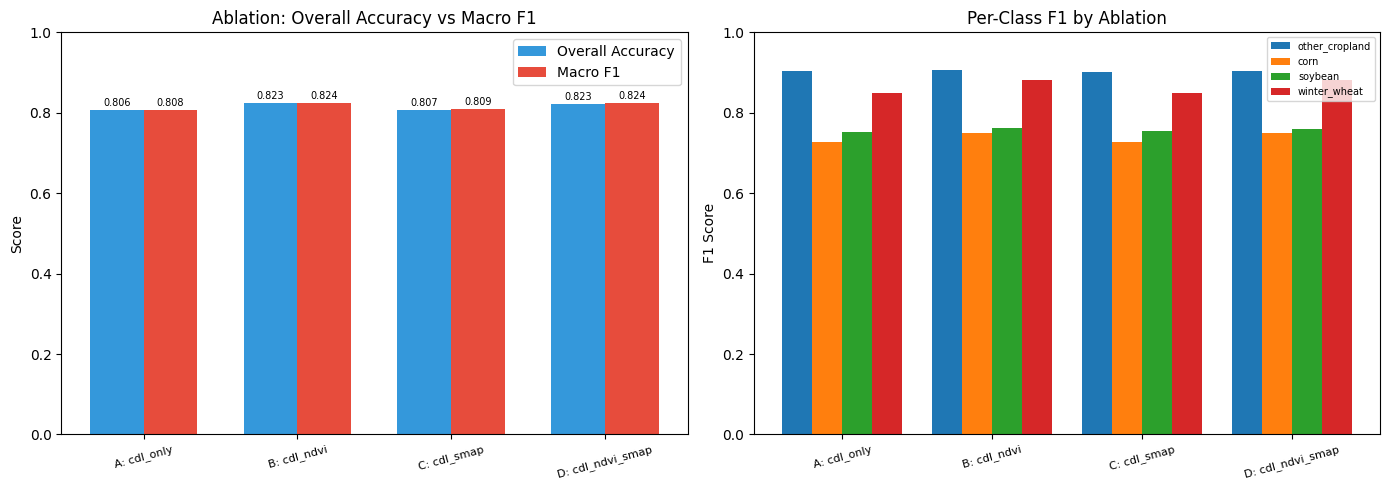

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = [f"{r['ablation_id']}: {r['name']}" for r in ablation_results]
x = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x - width / 2, results_df["overall_accuracy"], width, label="Overall Accuracy", color="#3498db")
axes[0].bar(x + width / 2, results_df["macro_f1"], width, label="Macro F1", color="#e74c3c")
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=8, rotation=15)
axes[0].set_ylabel("Score")
axes[0].set_title("Ablation: Overall Accuracy vs Macro F1")
axes[0].legend()
axes[0].set_ylim(0, 1)
for i, (acc, f1) in enumerate(zip(results_df["overall_accuracy"], results_df["macro_f1"])):
    axes[0].text(i - width / 2, acc + 0.01, f"{acc:.3f}", ha="center", fontsize=7)
    axes[0].text(i + width / 2, f1 + 0.01, f"{f1:.3f}", ha="center", fontsize=7)

f1_cols = [f"f1_{cn}" for cn in CLASS_NAMES]
bar_width = 0.2
for i, cn in enumerate(CLASS_NAMES):
    offsets = x + (i - 1.5) * bar_width
    axes[1].bar(offsets, results_df[f"f1_{cn}"], bar_width, label=cn)
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, fontsize=8, rotation=15)
axes[1].set_ylabel("F1 Score")
axes[1].set_title("Per-Class F1 by Ablation")
axes[1].legend(fontsize=7)
axes[1].set_ylim(0, 1)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "task4_ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Confusion Matrices (CDL-only vs CDL+NDVI+SMAP)

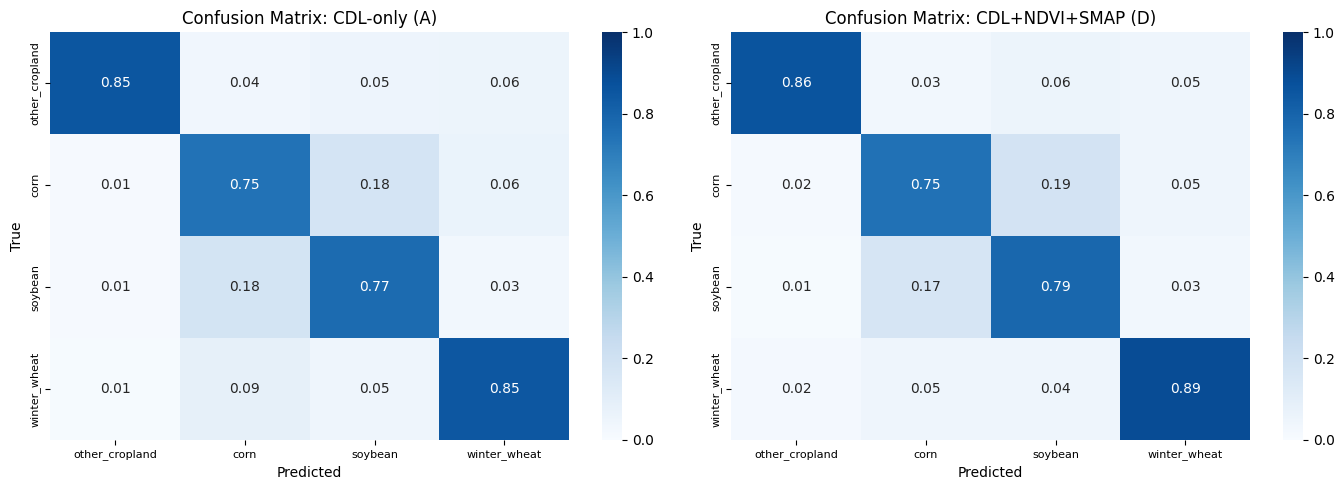

In [6]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (ab_id, title) in enumerate([("A", "CDL-only (A)"), ("D", "CDL+NDVI+SMAP (D)")]):
    y_true = val_df["label"].astype(int).values
    y_pred = ablation_preds[ab_id].astype(int)
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_pct, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=axes[idx], vmin=0, vmax=1,
    )
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")
    axes[idx].set_title(f"Confusion Matrix: {title}")
    axes[idx].tick_params(axis="both", labelsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "task4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Quantify NDVI and SMAP Value-Add

Delta in accuracy and macro F1 relative to the CDL-only baseline.

In [7]:
baseline = results_df[results_df["ablation_id"] == "A"].iloc[0]

print("Feature value-add relative to CDL-only baseline (A):")
print(f"{'':>20s} {'Δ Accuracy':>12s} {'Δ Macro F1':>12s}")
print("-" * 50)

for _, row in results_df.iterrows():
    if row["ablation_id"] == "A":
        continue
    d_acc = row["overall_accuracy"] - baseline["overall_accuracy"]
    d_f1 = row["macro_f1"] - baseline["macro_f1"]
    label = f"{row['ablation_id']}: {row['name']}"
    print(f"{label:>20s} {d_acc:>+12.4f} {d_f1:>+12.4f}")

Feature value-add relative to CDL-only baseline (A):
                       Δ Accuracy   Δ Macro F1
--------------------------------------------------
         B: cdl_ndvi      +0.0174      +0.0164
         C: cdl_smap      +0.0007      +0.0006
    D: cdl_ndvi_smap      +0.0167      +0.0159


## 7. Test-Year Evaluation (2023)

Train the best model (D: CDL+NDVI+SMAP) on the combined train+val set and evaluate on the held-out test year.

In [8]:
best_ab = ablation_configs[-1]  # D: cdl_ndvi_smap
best_feats = best_ab["features"]

trainval_df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Training final model on train+val ({len(trainval_df):,} rows), {len(best_feats)} features...")

split_idx = len(train_df)
final_train = trainval_df.iloc[:split_idx]
final_val = trainval_df.iloc[split_idx:]

final_clf = train_lightgbm_classifier(
    final_train, final_val, best_feats,
    hp=hp, early_stopping_rounds=es,
)

y_test_pred = final_clf.predict(test_df[best_feats])
test_metrics = evaluate_multiclass(test_df["label"].values, y_test_pred, class_names=CLASS_NAMES)

print(f"\nTest-Year ({cfg['panel']['test_year']}) Results:")
print(f"  Overall accuracy: {test_metrics['overall_accuracy']:.4f}")
print(f"  Macro F1:         {test_metrics['macro_f1']:.4f}")
for cname in CLASS_NAMES:
    print(f"  F1 {cname}: {test_metrics['per_class_f1_named'].get(cname, 0.0):.4f}")

stamp = datetime.now(timezone.utc).strftime("%Y%m%d")
test_metrics_path = TABLES_DIR / f"task4__test_metrics__{stamp}.json"
test_metrics_path.write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
print(f"\nWrote {test_metrics_path}")

Training final model on train+val (5,000,000 rows), 38 features...

Test-Year (2023) Results:
  Overall accuracy: 0.7921
  Macro F1:         0.7914
  F1 other_cropland: 0.8926
  F1 corn: 0.7260
  F1 soybean: 0.7347
  F1 winter_wheat: 0.8125

Wrote C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\artifacts\tables\task4\task4__test_metrics__20260413.json


In [9]:
model_path = MODELS_DIR / "crop_type_model.joblib"
save_model(final_clf, model_path)
print(f"Saved model to {model_path}")

pred_path = PROCESSED_DIR / "test_predictions_2023.parquet"
pred_df = test_df[["iy", "ix", "label", "year"]].copy()
if "rotation_regime" in test_df.columns:
    pred_df["rotation_regime"] = test_df["rotation_regime"]
pred_df["predicted"] = y_test_pred.astype(np.float32)
pred_df.to_parquet(pred_path, index=False, compression="zstd")
print(f"Saved test predictions to {pred_path}")

Saved model to C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\artifacts\models\task4\crop_type_model.joblib
Saved test predictions to C:\Users\sardo\OneDrive\Desktop\Classes\Projects\GeoCrop-Spatiotemporal-Modeling\data\processed\task4\test_predictions_2023.parquet


## 8. Test-Year Confusion Matrix

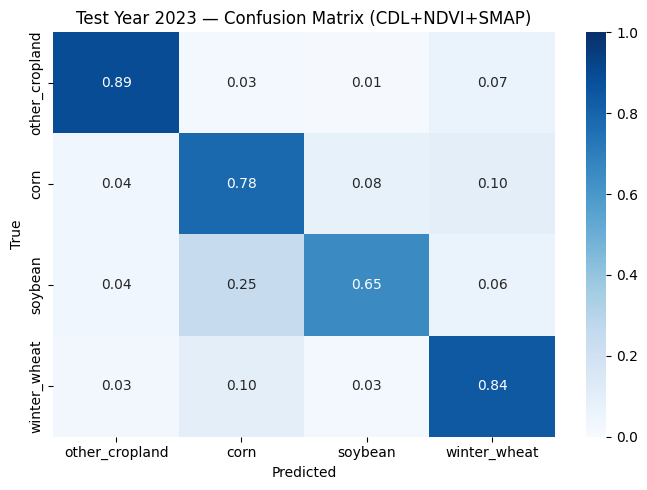

In [10]:
cm_test = confusion_matrix(test_df["label"].astype(int).values, y_test_pred.astype(int))
cm_test_pct = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_test_pct, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, vmin=0, vmax=1,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Test Year {cfg['panel']['test_year']} — Confusion Matrix (CDL+NDVI+SMAP)")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "task4_test_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

**Ablation study results** quantify the value-add of supplementary remote sensing features:
- **CDL-only (A)** provides the baseline — crop history alone is a strong predictor due to persistent rotation patterns.
- **Adding NDVI (B)** improves accuracy by capturing within-season phenological differences between crops (corn peaks later, winter wheat greens up earlier).
- **Adding SMAP (C)** provides soil-moisture context that helps distinguish crops grown under different hydrological conditions.
- **CDL+NDVI+SMAP (D)** combines both sources for the best overall performance.

The trained model and test predictions are saved for downstream analysis in Notebooks 03 (SHAP + rotation regime) and 04 (spatial maps).